<a href="https://colab.research.google.com/github/ck1894/NYU-Tandon-CS-GY-6923-Machine-Learning/blob/main/week4_lab3_regularization_logreg_gd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## Part 1: LASSO and Gradient Descent

In this part of the lab, we will implement L1-regularized linear regression and solve it using gradient descent. First, let us generate the data. We will apply `StandardScaler()` to the input features to make sure they are normalized which will make optimization easier.

Dataset shape: X_tr=(400, 10), y_tr=(400,), X_te=(100, 10), y_te=(100,)


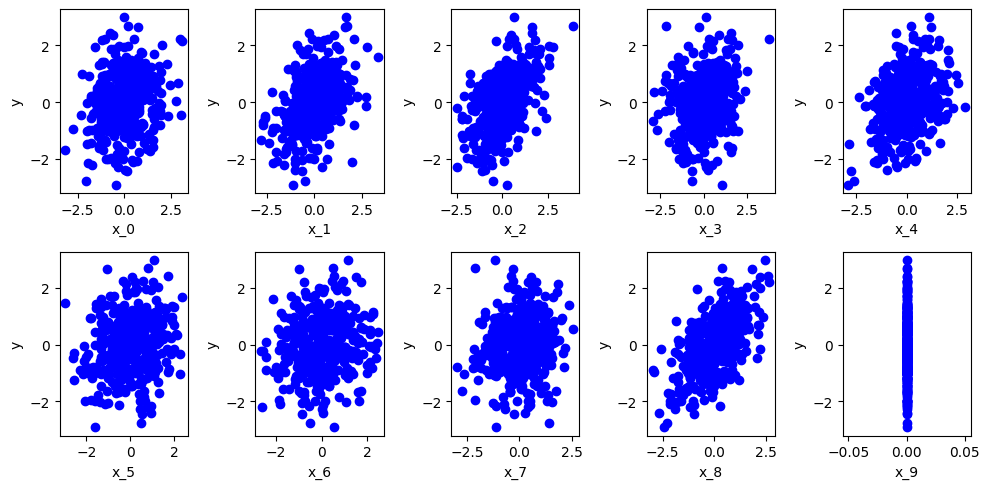

In [34]:
n_data = 500
n_train = 400
n_test = n_data - n_train
n_features = 10

X, y = make_regression(n_samples=n_data, n_features=n_features-1, noise=1, random_state=42) # create synthetic linear regression dataset
X = np.concat([X, np.ones((n_data, 1))], axis=1)
X = StandardScaler().fit_transform(X)
y -= y.mean()
y = y / np.std(y)
y = y.reshape(-1)


X_tr, X_te = X[:n_train], X[n_train:]
y_tr, y_te = y[:n_train], y[n_train:]

f, arr = plt.subplots(2, 5, figsize=(10, 5))
for i in range(10):
  arr[i // 5, i % 5].plot(X_tr[:, i], y_tr, "bo")
  arr[i // 5, i % 5].set_xlabel(f"x_{i}")
  arr[i // 5, i % 5].set_ylabel("y")


plt.tight_layout()
print(f"Dataset shape: X_tr={X_tr.shape}, y_tr={y_tr.shape}, X_te={X_te.shape}, y_te={y_te.shape}")

Recall that in $L_1$-regularized linear regression, the model predictions are given by
$$
\hat y = x^T w,
$$
where $\hat y \in \mathbb R$, $w \in \mathbb R^d$ and $x \in \mathbb R^d$. The loss is given by
$$
L(w) = \frac 1 n \|y - X w\|^2 + \lambda \|w\|_1,
$$
where $n$ is the number of datapoints, $y \in \mathbb R^n$, $X \in \mathbb R^{n \times d}$. Now, let us implement the loss in numpy.

Complete the function below. The loss you should get is approximately 6.

In [35]:
print(y.shape)
print(X.shape)

(500,)
(500, 10)


In [36]:
def compute_loss(X, y, w, lam):
    """
    Compute the total loss for L1-regularized linear regression.

    Parameters:
    -----------
    X : numpy.ndarray of shape (n, d)
        Feature matrix where n is number samples and d is number of features
    y : numpy.ndarray of shape (n,)
        Target values
    w : numpy.ndarray of shape (d,)
        Weight vector
    lam : float
        L1 regularization strength lambda (scalar)

    Returns:
    --------
    loss: float
        Combined MSE and L1 penalty, scalar
    """

    # TODO: YOUR CODE HERE!
    residual = y - X @ w  # 1d array (500, )
    mse = residual @ residual / X.shape[0]  # 1D arrays have no orientation in numpy
                                            # residual.T @ residual == residual @ residual
    l1 = lam * np.sum(np.abs(w))
    loss = mse + l1

    return loss

lam = 0.1
w = np.ones((n_features,))
compute_loss(X_tr, y_tr, w, lam)

np.float64(5.934029543783647)

We want to minimize this loss using gradient descent. The next step is to derive and implement the gradient of the loss: $\nabla_w L(w)$.

**Hint**: check the derivation of the gradient for the l2-regularized linear regression as we did in lecture 3 (slide 24 [here](https://docs.google.com/presentation/d/1_HRFPT9uRl8deCtj-DF1eNX_luFXmr2asUnHaBzf5MQ/edit?usp=sharing)). Be careful with the normalization: in the lecture we did not have the $\frac 1 n$ scaling factor for the data fit term $\|Xw - y\|^2$!

Use the identities
- $\frac{\partial}{\partial w}(w^TAw) = 2Aw$ for symmetric matrix $A$
- $\frac{\partial}{\partial w}(a^Tw) = a$ for vector $a$

**Hint**: The l1-regularization term is non-smooth when some of the components of $w$ are 0, you can assume that all components are non-zero here. You may get intuition for what the gradient will look by studying the derivative $\frac{d|u|}{du}$ for one-dimensional $u \in \mathbb R$.

In [37]:
X.shape

(500, 10)

In [38]:
def compute_gradient(X, y, w, lam):
    """
    Compute gradient of L1-regularized linear regression loss.

    Parameters:
    -----------
    X : numpy.ndarray of shape (n, d)
        Feature matrix where n is number samples and d is number of features
    y : numpy.ndarray of shape (n,)
        Target values
    w : numpy.ndarray of shape (d,)
        Weight vector
    lam : float
        L1 regularization strength lambda (scalar)

    Returns:
    --------
    gradient : numpy.ndarray of shape (d,)
        Gradient of the loss function with respect to w
    """
    # TODO: YOUR CODE HERE!
    """
    L(w) = (1/n) ||y - Xw||^2 + λ ||w||_1

    MSE term:
      (1/n) ||y - Xw||^2 = (1/n) (y - Xw)^T (y - Xw) = (1/n) [ y^T y - 2 y^T X w + w^T X^T X w ]
      ∇_w ( (1/n) ||y - Xw||^2 ) = (1/n) [ 2 X^T X w - 2 X^T y ] = (2/n) X^T (Xw - y)
      (X.shape (500,10), XT.shape (10, 500), (Xw - y).shape (500, ), (X^T (Xw - y)).shape (10, ))

    L1 term:
      λ ||w||_1 = λ * sum_i |w_i|
      ∇_w ( λ sum_i |w_i| )
      =
      [
        ∂/∂w_1 (λ sum_i |w_i|),
        ∂/∂w_2 (λ sum_i |w_i|),
        ...
      ]
      All terms except |w_j| are constants with respect to w_j.
      = λ * d/dw_i |w_i| = λ * sign(w_i) = λ * sign(w)
      sign(w) =
      [
        sign(w_1),
        sign(w_2),
        ...
      ]

    Combine both parts:
      ∇L(w) = (2/n) X^T (Xw - y) + λ sign(w)
    """
    grad_mse = (2 / X.shape[0]) * (X.T @ (X @ w - y))
    grad_l1 = lam * np.sign(w)
    gradient = grad_mse + grad_l1

    return gradient


w = np.random.randn(n_features,)
compute_gradient(X_tr, y_tr, w, lam)

array([ 0.61414535, -1.41681068,  0.24984261,  3.53288435, -1.36867229,
       -0.71795533,  3.21537013,  1.57616135, -2.19973967,  0.1       ])

We can check the implementation of the gradient numerically by comparing it to a finite difference approximation. Run the code below. If you implemented both the loss and the gradient correctly, you should get a small number below $10^{-6}$.

In [39]:
from scipy.optimize import check_grad

lam = 0.1
w0 = np.random.randn(n_features,)

def f(w):
  return compute_loss(X_tr, y_tr, w, lam)

def g(w):
  return compute_gradient(X_tr, y_tr, w, lam)

print(check_grad(f, g, w0)) # check_grad computes gradient using loss function and compares against our calculated gradient using L2 distance at a random point w0

3.6465048993209115e-07


Now that we computed the gradient, we can do gradient descent! Recall that the update rule is given by:
$$w_{k+1} = w_k - \alpha \nabla_w L(w_k).$$

Please implement gradient descent by completing the function below. Make use of the functions `compute_gradient` and `compute_loss` that you implemented above.

Along with the final value of w, return the list of values of the loss $L(w_k)$ for each iteration $k$.

Text(0, 0.5, 'Loss')

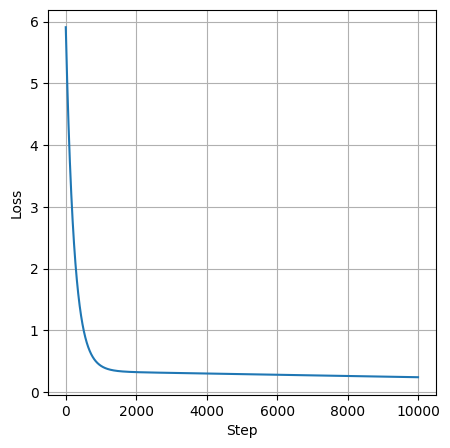

In [40]:
def gradient_descent(X, y, w_init, lam, alpha, num_iter=10000
                     ):
    """
    Compute gradient of L1-regularized linear regression loss.

    Parameters:
    -----------
    X : numpy.ndarray of shape (n, d)
        Feature matrix where n is number samples and d is number of features
    y : numpy.ndarray of shape (n,)
        Target values
    w_init : numpy.ndarray of shape (d,)
        Initial weight vector
    lam : float
        L1 regularization strength lambda
    num_iter: int
      number of iterations of gradient decent to run

    Returns:
    --------
    w_final : numpy.ndarray of shape (d,)
        Final value of parameters w
    loss_history: list[float]
        List of loss values at each iteration
    """

    # Initialize weights and loss history
    w = w_init.copy()  # Make a copy to avoid modifying the input
    loss_history = []

    # Perform gradient descent
    for i in range(num_iter):
      # TODO: YOUR CODE HERE!
      gradient = compute_gradient(X, y, w, lam)
      w -= alpha * gradient
      loss = compute_loss(X, y, w, lam)
      loss_history.append(loss)

    return w, loss_history


w_init = np.ones((n_features,))
w, loss_history = gradient_descent(X_tr, y_tr, w_init, lam=0.1, alpha=.001)

f, ax = plt.subplots(1, 1, figsize=(5, 5))
xs = np.arange(len(loss_history))
ys = np.array(loss_history)

ax.plot(xs, ys)
ax.grid()
ax.set_xlabel("Step")
ax.set_ylabel("Loss")


Run gradient descent with different learning rates. Add your code for these experiments below.

Explain the results: write a couple of sentences on what do you see depending on the different learning rate and why.

**Add your explanation here:**

In [41]:
alphas = [1, 0.1, 0.01, 0.001, 0.0001]

for alpha in alphas:
  w_init = np.ones((n_features,))
  w, loss_history = gradient_descent(X_tr, y_tr, w_init, lam=0.1, alpha=alpha)
  print(f"alpha={alpha:>4}: final loss={loss_history[-1]:.4f}")

/tmp/ipykernel_151/1038257720.py:24: RuntimeWarning: overflow encountered in matmul
  mse = residual @ residual / X.shape[0]  # 1D arrays have no orientation in numpy
/tmp/ipykernel_151/160128516.py:51: RuntimeWarning: overflow encountered in matmul
  grad_mse = (2 / X.shape[0]) * (X.T @ (X @ w - y))
/tmp/ipykernel_151/160128516.py:51: RuntimeWarning: invalid value encountered in matmul
  grad_mse = (2 / X.shape[0]) * (X.T @ (X @ w - y))
/tmp/ipykernel_151/1727187555.py:35: RuntimeWarning: invalid value encountered in subtract
  w -= alpha * gradient


alpha=   1: final loss=nan
alpha= 0.1: final loss=0.2430
alpha=0.01: final loss=0.2430
alpha=0.001: final loss=0.2430
alpha=0.0001: final loss=0.4275


- **α = 1**
  - Final loss: `nan`
  - Gradient descent diverged (overflow warnings).
  - Learning rate is too large and causes unstable updates.

- **α = 0.1, 0.01, 0.001**
  - Final loss: ≈ `0.2430`
  - All converge successfully to approximately the same minimum.
  - These learning rates are stable.

- **α = 0.0001**
  - Final loss: `0.4275`
  - Converges too slowly and does not reach the minimum within the given number of iterations.

Recall that l1 linear regression will set some of the parameters of w to zero. Let's see how many parameters will be set to zero as a function of regularization strength. Run the cell below.

Text(0, 0.5, 'number of zeros in w*')

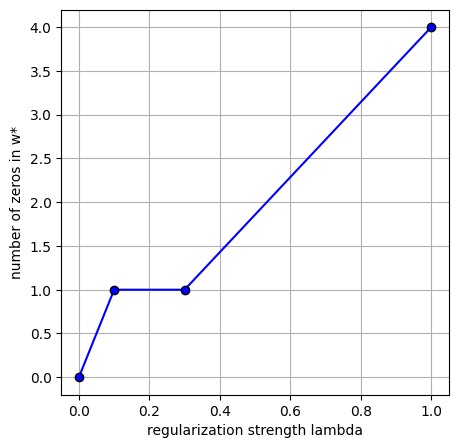

In [42]:
lambdas = [0., 1e-1, 3e-1, 1]
num_zeros = []

for lam in lambdas:
  w_init = np.ones((n_features,))
  w, loss_history = gradient_descent(X_tr, y_tr, w_init, lam=lam, alpha=.1, num_iter=1000)
  num_zeros.append(np.sum(w < 1.e-6))


f, ax = plt.subplots(1, 1, figsize=(5, 5))
xs = lambdas
ys = num_zeros

ax.plot(xs, ys, "-bo", mec="k")
ax.grid()
ax.set_xlabel("regularization strength lambda")
ax.set_ylabel("number of zeros in w*")

Explain the results: write a couple of sentences on what do you see depending on the different value of $\lambda$ and why.

**Add your explanaiton here:**

From the plot, we see a clear increasing trend where as λ increases, the number of zero coefficients in w increases.

When λ = 0, no coefficients are zero because there is no regularization penalty.  
For λ values from ~0.1 to ~0.3, only one coefficient is pushed to zero.
For larger λ = 1, four coefficients become zero.

This happens because L1 regularization penalizes the absolute value of the weights. As λ becomes larger, the penalty term dominates the loss function, forcing more coefficients to shrink exactly to zero. This explains why L1 regularization produces sparse models.

## Part 2: Logistic Regression via Stochastic Gradient Descent

This part of the lab demonstrates multi-class logistic regression (softmax regression) using PyTorch.
We'll classify handwritten digits from the MNIST dataset using a linear model with
L2 regularization and analyze the impact of regularization strength on model performance.

In [43]:
import torch # Core library
import torch.nn as nn # Neural network building blocks
import torch.optim as optim # Optimization algorithms (training)
import torch.nn.functional as F # Functional (use functions instead of objects) versions of layers / ops
from torch.utils.data import DataLoader # Handles batching + iteration
from torchvision import datasets, transforms # Ready-made datasets, preprocessing pipeline
import numpy as np
import matplotlib.pyplot as plt

In [44]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

First, let's load the data. In pytorch, we will use [DataLoader](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html) objects which allow us to iterate over the dataset producing batches of training examples instead of working with the full dataset directly. This will make it convenient to implement SGD.

Read the code below carefully and make sure you understand it.

In [45]:
def load_mnist_data(batch_size=64): # batch_size=64: load 64 images at a time
    """
    Load and preprocess MNIST dataset.

    MNIST contains 28x28 grayscale images of handwritten digits (0-9).
    We'll flatten the images to 784-dimensional vectors for logistic regression.

    Args:
        batch_size (int): Number of samples per batch

    Returns:
        train_loader, test_loader: DataLoader objects for training and testing
    """

    # Define transformations: convert to tensor and normalize
      # A tensor is just a multi-dimensional array (like NumPy), but designed for machine learning with GPU support and gradient tracking
    # Normalization helps with gradient descent convergence
    transform = transforms.Compose([
        transforms.ToTensor(),  # Convert PIL (Python Imaging Library) image (0-255 pixel values) to tensor and scale to [0,1]
        transforms.Normalize((0.1307,), (0.3081,))  # Normalize with MNIST mean and std
                                                    # (0.1307,), (0.3081,) are the mean and standard deviation of MNIST (1 channel), used to normalize pixel values to have mean ~0 and std ~1.
    ])

    # Load training dataset
    train_dataset = datasets.MNIST(
        root='./data', # Where the dataset is stored locally
        train=True, # Which split to load
        download=True, # Download if dataset is not already present
        transform=transform # Every time you give me an image, apply this pipeline
    )

    # Load test dataset
    test_dataset = datasets.MNIST(
        root='./data',
        train=False,
        download=True,
        transform=transform
    )

    # Create data loaders for batch processing
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size, # Splits data into batches of 64
        shuffle=True  # Shuffle training data for better SGD performance
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False  # No need to shuffle test data
    )

    print(f"Training samples: {len(train_dataset)}")
    print(f"Test samples: {len(test_dataset)}")
    print(f"Batch size: {batch_size}")

    return train_loader, test_loader


train_loader, test_loader = load_mnist_data()

Training samples: 60000
Test samples: 10000
Batch size: 64


Let's load the first batch and look at the shapes of the data it returns.

In [46]:
batch = next(iter(train_loader)) # train_loader → collection of batches
                                 # iter(train_loader) → creates an iterator
                                 # next(...) → gets the first batch

x, y = batch # x → input images, y → labels

print(f"{x.shape=}, {y.shape=}")  # x.shape=torch.Size([64, 1, 28, 28]): 64 images (batch size), 1 channel (grayscale), 28×28 pixels,
                                  # y.shape=torch.Size([64]): 64 labels

print(f"{len(train_loader)=}") # Number of batches (60,000 samples / 64 per batch ≈ 937.5 → 938 batches)

x.shape=torch.Size([64, 1, 28, 28]), y.shape=torch.Size([64])
len(train_loader)=938


When we will iterate over the `train_loader`, each iteration will return a batch containing 64 images of shape `1x28x28` and the corresponding labels. The number of batches in the iterator is `60000 / 64 = 938` (where we round the division up). Let's look at the data.

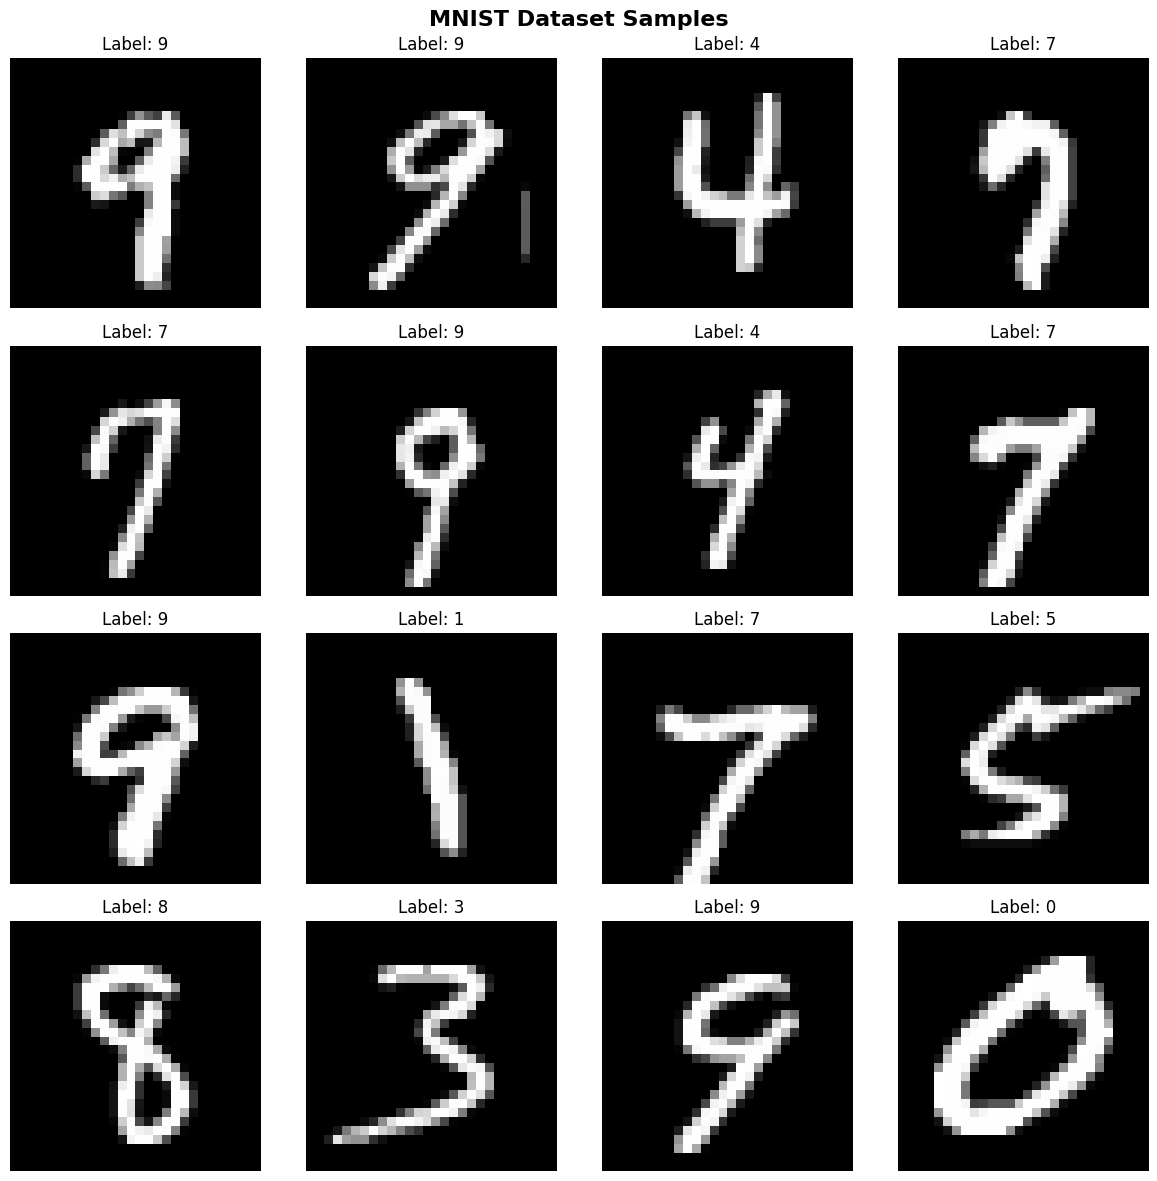

Image shape: torch.Size([1, 28, 28])
After flattening: torch.Size([784])
Data type: torch.float32
Value range: [-0.424, 2.821]


In [47]:
def visualize_mnist_samples(train_loader, num_samples=16):
    """
    Visualize random samples from the MNIST dataset.

    This function helps students understand what the input data looks like
    before it gets flattened and fed into the logistic regression model.

    Args:
        train_loader: DataLoader for training data
        num_samples: Number of samples to display (should be a perfect square)
    """
    # Get a batch of data
    data_iter = iter(train_loader)
    images, labels = next(data_iter)

    # Create subplot grid
    rows = int(np.sqrt(num_samples))
    cols = rows

    plt.figure(figsize=(12, 12))
    plt.suptitle('MNIST Dataset Samples', fontsize=16, fontweight='bold')

    for i in range(num_samples):
        plt.subplot(rows, cols, i + 1)

        # Convert tensor to numpy and remove channel dimension
        # Shape: (1, 28, 28) -> (28, 28)
        img = images[i].squeeze().numpy()

        # Display image
        plt.imshow(img, cmap='gray')
        plt.title(f'Label: {labels[i].item()}', fontsize=12)
        plt.axis('off')  # Remove axis ticks and labels

    plt.tight_layout()
    plt.show()

    print(f"Image shape: {images[0].shape}")
    print(f"After flattening: {images[0].view(-1).shape}")
    print(f"Data type: {images[0].dtype}")
    print(f"Value range: [{images[0].min().item():.3f}, {images[0].max().item():.3f}]")

visualize_mnist_samples(train_loader)

Now, let us implement the logistic regression model as a `torch.nn.Module`. Carefully study the implementation below and make sure you understand how it works and what each line is doing.

In [48]:
class LogisticRegression(nn.Module): # Implementing logistic regression as a single-layer neural network
                                     # In PyTorch, you define the model and training process yourself instead of using a fully packaged function like .fit() in sklearn
    """
    Multi-class Logistic Regression (Softmax Regression) model.

    This is a linear classifier that maps input features directly to class logits.
    The softmax function converts logits to probabilities for multi-class classification.

    Architecture: Input (784) -> Linear -> Output (10 classes)
    """

    def __init__(self, input_dim=784, num_classes=10):
        """
        Initialize the logistic regression model.

        Args:
            input_dim (int): Number of input features (784 for flattened 28x28 images)
            num_classes (int): Number of output classes (10 for digits 0-9)
        """
        super(LogisticRegression, self).__init__() # Call the parent class constructor (Parent = nn.Module)
                                                    # nn.Module = base engine
                                                    # super().__init__() = "turn on the engine"

        # Single linear layer: y = Wx + b
        # This maps from 784-dimensional input to 10-dimensional output (logits)
        self.linear = nn.Linear(input_dim, num_classes)

        # Initialize weights with small random values
        # Good initialization is important for gradient descent convergence
        nn.init.normal_(self.linear.weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.linear.bias)

    def forward(self, x):
        """
        Forward pass through the model.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, 1, 28, 28)

        Returns:
            torch.Tensor: Raw logits of shape (batch_size, num_classes)
        """
        # Flatten the input images: (batch_size, 1, 28, 28) -> (batch_size, 784)
        # Flatten because model (z=Wx+b) expects a vector, not a 2D image
          # x.size(0) → batch size (64)
          # -1 → “figure out the rest automatically”
        x = x.view(x.size(0), -1)

        # Apply linear transformation to get logits (each image → 10 numbers (one per class))
        logits = self.linear(x)

        return logits

The magic of PyTorch is that it allows us to compute gradients automatically! Consider the example below.

Here, we use PyTorch to automatically compute the gradients of the quadratic form $w^T A w$. We derived it in the lecture, it took a bit of work. Now, we can compute the gradients with a few lines of code!

** sklearn computes gradients for predefined models (each model comes with a fixed loss function), but PyTorch can compute gradients for any loss function you define which is the real power.

In [49]:
# Set random seed for reproducibility
torch.manual_seed(42)

# Create a 3D vector w with gradient tracking enabled
# A tensor is just a multi-dimensional array (like NumPy), but designed for machine learning with GPU support and gradient tracking
  # requires_grad=True → tells PyTorch: “Track operations on this — I want gradients”
w = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)

# Create a random 3x3 matrix and make it symmetric
A_random = torch.randn(3, 3)
A = (A_random + A_random.T) / 2  # Make symmetric: A = (A + A^T) / 2

print("Vector w:")
print(w)
print("\nSymmetric matrix A:")
print(A)

# Compute the quadratic form: loss = w^T A w
loss = torch.matmul(torch.matmul(w.T, A), w)

print(f"\nQuadratic form w^T A w = {loss.item():.4f}")

# Compute gradients using backpropagation
loss.backward()

# Access the computed gradient
print(f"\nGradient ∇_w(w^T A w):")
print(w.grad)

# Verify manually: gradient of w^T A w is (A + A^T) w = 2Aw (since A is symmetric)
expected_grad = 2 * torch.matmul(A, w.detach())
print(f"\nExpected gradient (2Aw):")
print(expected_grad)

print(f"\nGradients match: {torch.allclose(w.grad, expected_grad)}")

Vector w:
tensor([1., 2., 3.], requires_grad=True)

Symmetric matrix A:
tensor([[ 0.3367,  0.1796,  1.2213],
        [ 0.1796, -1.1229, -0.4122],
        [ 1.2213, -0.4122,  0.4617]])

Quadratic form w^T A w = 3.1005

Gradient ∇_w(w^T A w):
tensor([ 8.7197, -6.6053,  3.5640])

Expected gradient (2Aw):
tensor([ 8.7197, -6.6053,  3.5640])

Gradients match: True


Now, let us implement L2-regularized logistic regression loss.

In [50]:
def l2_regularized_cross_entropy_loss(logits, targets, model, lambda_reg=0.01):
    """
    Compute cross-entropy loss with L2 regularization.

    This function combines the standard cross-entropy loss with an L2 penalty
    on the model weights to prevent overfitting. The total loss is:

    Loss = CrossEntropy(logits, targets) + λ * ||W||²

    where λ (lambda_reg) controls the strength of regularization.

    Args:
        logits (torch.Tensor): Raw model outputs (before softmax), shape (batch_size, num_classes)
        targets (torch.Tensor): True class labels, shape (batch_size,)
        model (nn.Module): The model (needed to access weights for regularization)
        lambda_reg (float): L2 regularization strength

    Returns:
        total_loss: Combined loss used for backpropagation
    """
    # Compute standard cross-entropy loss
    # F.cross_entropy applies softmax internally and computes negative log-likelihood
    ce_loss = F.cross_entropy(logits, targets)

    # Compute L2 regularization penalty
    # Sum of squares of all model parameters (weights and biases)
    l2_penalty = torch.sum(model.linear.weight**2)

    # Combine cross-entropy loss with L2 penalty
    total_loss = ce_loss + lambda_reg * l2_penalty

    """
    total_loss is a scalar tensor that carries a computation graph, so .backward() works
    because PyTorch knows how it was computed and can apply the chain rule.
    """
    return total_loss



model = LogisticRegression() # parameters (W, b) are created (randomly initialized)
data, targets = next(iter(train_loader)) # using one batch

# Forward pass
logits = model(data)

# Compute loss (including L2 regularization)
  # this loss is calculated using the randomly initiated parameters + one batch of data
loss = l2_regularized_cross_entropy_loss(logits, targets, model)

Print out the gradient of the loss we computed above on the given batch of data with respect to weights and biases of the model.

In [51]:
# compute the loss...
# TODO: Your code goes here!
loss.backward() # Backpropagate (compute gradients)

print("Gradient for weights:\n", model.linear.weight.grad)
print("\nGradient for biases:\n", model.linear.bias.grad)

Gradient for weights:
 tensor([[-0.0086, -0.0090, -0.0088,  ..., -0.0087, -0.0091, -0.0090],
        [ 0.0171,  0.0173,  0.0169,  ...,  0.0170,  0.0170,  0.0170],
        [-0.0122, -0.0124, -0.0123,  ..., -0.0122, -0.0120, -0.0124],
        ...,
        [-0.0016, -0.0018, -0.0017,  ..., -0.0017, -0.0015, -0.0015],
        [-0.0081, -0.0076, -0.0078,  ..., -0.0078, -0.0082, -0.0080],
        [ 0.0527,  0.0528,  0.0529,  ...,  0.0530,  0.0526,  0.0527]])

Gradient for biases:
 tensor([ 0.0213, -0.0400,  0.0291,  0.0170, -0.0594,  0.0484,  0.0852,  0.0038,
         0.0190, -0.1245])


Now, let's train the model! We will use the SGD implementation from pytorch. Read the following code carefully and make sure you understand it: it will be very relevant when we start training neural networks!

Starting training...
--------------------------------------------------
Epoch 1/2, Batch 0, Loss: 2.3426
Epoch 1/2, Batch 200, Loss: 0.6138
Epoch 1/2, Batch 400, Loss: 0.5528
Epoch 1/2, Batch 600, Loss: 0.5477
Epoch 1/2, Batch 800, Loss: 0.4375
Epoch 1/2: Avg Loss = 0.5121
Epoch 2/2, Batch 0, Loss: 0.4111
Epoch 2/2, Batch 200, Loss: 0.4063
Epoch 2/2, Batch 400, Loss: 0.3782
Epoch 2/2, Batch 600, Loss: 0.2692
Epoch 2/2, Batch 800, Loss: 0.3173
Epoch 2/2: Avg Loss = 0.3970
--------------------------------------------------
Training completed!


Text(0, 0.5, 'loss')

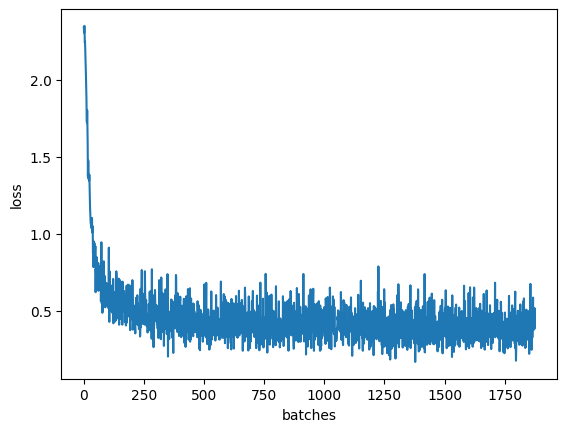

In [52]:
def train_model(model, train_loader, lambda_reg=0.01, learning_rate=0.01, num_epochs=10):
    """
    Train the logistic regression model using SGD with L2 regularization.

    Args:
        model: The neural network model
        train_loader: DataLoader for training data
        device: Device to run computations on
        lambda_reg: L2 regularization strength
        learning_rate: Learning rate for SGD
        num_epochs: Number of training epochs

    Returns:
        lists of training losses per epoch
    """
    model.train()  # Set model to training mode

    # Create optimizer (SGD with momentum for better convergence)
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

    train_losses = []
    train_accuracies = []

    print("Starting training...")
    print("-" * 50)

    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for batch_idx, (data, targets) in enumerate(train_loader):

            # Forward pass
            logits = model(data)

            # Compute loss using our custom function
            total_loss = l2_regularized_cross_entropy_loss(
                logits, targets, model, lambda_reg
            )

            # Backward pass
            optimizer.zero_grad()  # Clear gradients from previous step
                                   # PyTorch accumulates gradients by default, so without this line, gradients from previous batches would keep adding up.
            total_loss.backward()  # Compute gradients
            optimizer.step()       # Update parameters (param = param - lr * param.grad)

            # Accumulate statistics
            epoch_loss += total_loss.item()
            train_losses.append(total_loss.item())

            # Print progress every 200 batches
            if batch_idx % 200 == 0:
                print(f'Epoch {epoch+1}/{num_epochs}, Batch {batch_idx}, '
                      f'Loss: {total_loss.item():.4f}')

        # Calculate epoch statistics
        avg_loss = epoch_loss / len(train_loader)

        print(f'Epoch {epoch+1}/{num_epochs}: Avg Loss = {avg_loss:.4f}')

    print("-" * 50)
    print("Training completed!")

    return train_losses


model = LogisticRegression()
train_losses = train_model(model, train_loader, lambda_reg=0.01, learning_rate=0.001, num_epochs=2)

plt.plot(train_losses)
plt.xlabel("batches")
plt.ylabel("loss")

Now, let us evaluate the model that we trained! You will need to fist compute the predictions on each datapoint in the `test_loader` and store them in a numpy array. Make use of `model.forward` to compute the logits, and then convert them to predictions. You will also need to return the true class labels for all of the test examples.

In [53]:
def evaluate_predictions_labels(model, test_loader):
    """
    Returns model predictions and true labels on the given dataloader.

    Args:
        model: Trained neural network model
        test_loader: DataLoader for test data

    Returns:
        all_predictions: numpy array of shape (n_test_data,), all test predictions
        all_targets: numpy array of shape (n_test_data,), all test ground truth labels
    """
    model.eval()  # Set model to evaluation mode (disables dropout, etc.)

    all_predictions = []
    all_targets = []

    # Disable gradient computation for efficiency
    with torch.no_grad():
        for data, targets in test_loader:
            # TODO: Your code goes here!
            logits = model(data)
            preds = torch.argmax(logits, dim=1) # pick class with highest score (dim=1 → across columns (within each sample))
            all_predictions.extend(preds.numpy()) # .extend() adds multiple elements to a list (one by one)
            all_targets.extend(targets.numpy())   # so it creates one flat list across all batches, while .append() would create a nested list with one entry per batch.

    # Convert to numpy arrays
    all_predictions = np.array(all_predictions)
    all_targets = np.array(all_targets)
    return all_predictions, all_targets

all_predictions, all_targets = evaluate_predictions_labels(model, test_loader)
print(f"{all_predictions.shape=}, {all_targets.shape=}")

all_predictions.shape=(10000,), all_targets.shape=(10000,)
all_predictions.shape=(10000,), all_targets.shape=(10000,)


Now, let's implement the accuracy metric for this model.

In [54]:
def accuracy(all_predictions, all_targets):
  # TODO: Your code goes here!
  return np.mean(all_predictions == all_targets)

accuracy(all_predictions, all_targets)

np.float64(0.9123)

We now got our first MNIST classifier! You should see an accuracy around 85-90%.

Now, experiment with the L2 regularization parameter in the model. What happens to accuracy if you set the regularization strength to 10? What if you set it to 0?

Provide your code and write a couple of sentences explaining the results.

In [ ]:
for lam in [0.0, 0.01, 10.0]:
  model = LogisticRegression()
  train_losses = train_model(model, train_loader, lambda_reg=lam, learning_rate=0.05, num_epochs=5)
  all_predictions, all_targets = evaluate_predictions_labels(model, test_loader)
  print(f"lambda_reg={lam}: test accuracy={accuracy(all_predictions, all_targets):.4f}")

Starting training...
--------------------------------------------------
Epoch 1/5, Batch 0, Loss: 2.3481
Epoch 1/5, Batch 200, Loss: 0.5368
Epoch 1/5, Batch 400, Loss: 0.7495
Epoch 1/5, Batch 600, Loss: 0.3345
Epoch 1/5, Batch 800, Loss: 0.3345
Epoch 1/5: Avg Loss = 0.7076
Epoch 2/5, Batch 0, Loss: 0.3588
Epoch 2/5, Batch 200, Loss: 0.6281
Epoch 2/5, Batch 400, Loss: 0.4070
Epoch 2/5, Batch 600, Loss: 0.8734
Epoch 2/5, Batch 800, Loss: 0.7268
Epoch 2/5: Avg Loss = 0.6437
Epoch 3/5, Batch 0, Loss: 0.8115
Epoch 3/5, Batch 200, Loss: 0.5335
Epoch 3/5, Batch 400, Loss: 1.1736
Epoch 3/5, Batch 600, Loss: 0.0335
Epoch 3/5, Batch 800, Loss: 0.6818
Epoch 3/5: Avg Loss = 0.6245
Epoch 4/5, Batch 0, Loss: 1.0022
Epoch 4/5, Batch 200, Loss: 0.4935
Epoch 4/5, Batch 400, Loss: 0.7801
Epoch 4/5, Batch 600, Loss: 0.6163
Epoch 4/5, Batch 800, Loss: 1.0849
Epoch 4/5: Avg Loss = 0.6065
Epoch 5/5, Batch 0, Loss: 0.7348
Epoch 5/5, Batch 200, Loss: 0.3592
Epoch 5/5, Batch 400, Loss: 0.8410
Epoch 5/5, Batch 

When λ = 0, there is no regularization, so the model is free to learn large weights. In our experiment, this gave the highest test accuracy (about 85%). When λ = 0.01, the test accuracy dropped slightly (about 82%), and when λ = 10, the accuracy dropped dramatically (about 19%).

As λ increases, the L2 penalty forces the weights to become smaller. A very large λ (like 10) heavily penalizes the weights, making them close to zero. This prevents the model from learning meaningful patterns, leading to severe underfitting and very low accuracy.

In many situations, a small positive λ (like 0.01) can actually perform better than λ = 0. A small amount of regularization can reduce overfitting by preventing the model from learning noise in the training data. In our case, we only trained for 5 epochs, so the model likely did not overfit yet, which is why λ = 0 performed best. If we trained for more epochs or used a more complex model, a small λ could potentially outperform λ = 0.